# Amazon Sales Data Analysis — Clustering

Applies feature scaling and K-Means clustering to identify groups of products with similar sales and product characteristics.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [4]:
df = pd.read_csv("amazon_products.csv")

df = df.dropna(subset=[
    "product_rating",
    "total_reviews",
    "purchased_last_month",
    "discounted_price",
    "original_price",
    "discount_percentage",
    "product_category",
    "is_sponsored"
]).copy()

df["price_gap"] = df["original_price"] - df["discounted_price"]

df_model = df[[
    "product_rating",
    "total_reviews",
    "discounted_price",
    "original_price",
    "discount_percentage",
    "price_gap",
    "product_category",
    "is_sponsored"
]].copy()

df_model = pd.get_dummies(df_model, columns=["product_category", "is_sponsored"], drop_first=True)

print(df_model.head())
print(df_model.shape)

   product_rating  total_reviews  discounted_price  original_price  \
0             4.6          375.0             89.68          159.00   
1             4.3         2457.0              9.99           15.99   
2             4.6         3044.0            314.00          349.00   
3             4.6        35882.0            162.24          162.24   
4             4.8        28988.0             72.74           72.74   

   discount_percentage  price_gap  product_category_Chargers & Cables  \
0                43.60      69.32                               False   
1                37.52       6.00                               False   
2                10.03      35.00                               False   
3                 0.00       0.00                               False   
4                 0.00       0.00                               False   

   product_category_Gaming  product_category_Headphones  \
0                    False                        False   
1                    F

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

print(X_scaled.shape)

(30228, 21)


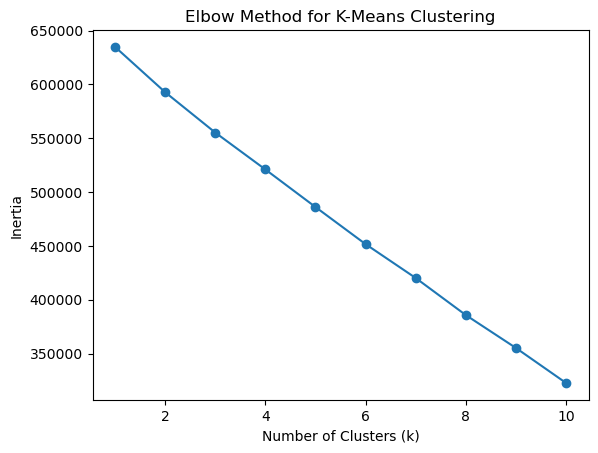

In [8]:
inertias = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(k_values, inertias, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Clustering")
plt.show()

In [9]:
print("The graph does not show a very clear elbow, but it starts to level off around k = 3. This means that adding more clusters after 3 does not improve the model much. Because of this, I chose k = 3 as a good number of clusters.")

The graph does not show a very clear elbow, but it starts to level off around k = 3. This means that adding more clusters after 3 does not improve the model much. Because of this, I chose k = 3 as a good number of clusters.


In [10]:
final_k = 3

kmeans_final = KMeans(n_clusters=final_k, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)

df_model["cluster"] = clusters

print(df_model["cluster"].value_counts())

cluster
1    23186
2     6074
0      968
Name: count, dtype: int64


In [11]:
centroids = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=df_model.drop("cluster", axis=1).columns
)

print(centroids)

   product_rating  total_reviews  discounted_price  original_price  \
0       -1.047882      -0.236185          4.026367        4.260231   
1        0.157429      -0.004083         -0.109811       -0.121522   
2       -0.433949       0.053227         -0.222496       -0.215064   

   discount_percentage  price_gap  product_category_Chargers & Cables  \
0             0.437908   2.090692                            0.068302   
1            -0.053659  -0.069909                            0.057927   
2             0.135041  -0.066328                           -0.232008   

   product_category_Gaming  product_category_Headphones  \
0                -0.122653                    -0.183626   
1                 0.037252                    -0.183626   
2                -0.122653                     0.730212   

   product_category_Laptops  ...  product_category_Other Electronics  \
0                  0.859505  ...                           -0.360278   
1                  0.094998  ...             

In [12]:
for i in range(final_k):
    print("Cluster", i)
    print(centroids.loc[i].sort_values(ascending=False).head(8))
    print()

Cluster 0
original_price                        4.260231
discounted_price                      4.026367
price_gap                             2.090692
product_category_Wearables            1.085283
product_category_Laptops              0.859505
discount_percentage                   0.437908
product_category_Networking           0.345653
product_category_Chargers & Cables    0.068302
Name: 0, dtype: float64

Cluster 1
product_rating                        0.157429
product_category_Other Electronics    0.135766
product_category_Laptops              0.094998
product_category_Power & Batteries    0.094486
product_category_TV & Display         0.059251
product_category_Chargers & Cables    0.057927
product_category_Speakers             0.054365
product_category_Storage              0.053938
Name: 1, dtype: float64

Cluster 2
product_category_Phones        1.784418
product_category_Headphones    0.730212
is_sponsored_Sponsored         0.286111
discount_percentage            0.135041
total_re

In [3]:
print("After running K-Means with k = 3, the products were grouped into three different clusters.")

print("Cluster 0 looks like higher-priced products. It has the highest values for original_price, discounted_price, and price_gap. It also includes more items in categories like Wearables and Laptops. This suggests these are more expensive products where price plays a big role.")

print("Cluster 1 seems more like a middle group. The values are not super high or low, so these look like more average products. It includes a mix of categories like Other Electronics and Laptops.")

print("Cluster 2 seems focused more on specific categories like Phones and Headphones. It also has some positive values for sponsored products and total reviews, which could mean these items get more attention or promotion.")

print("Overall, the clusters show that products can be grouped based on price, category, and how much attention they get from customers. Not all products behave the same, and these clusters help show those differences.")

After running K-Means with k = 3, the products were grouped into three different clusters.
Cluster 0 looks like higher-priced products. It has the highest values for original_price, discounted_price, and price_gap. It also includes more items in categories like Wearables and Laptops. This suggests these are more expensive products where price plays a big role.
Cluster 1 seems more like a middle group. The values are not super high or low, so these look like more average products. It includes a mix of categories like Other Electronics and Laptops.
Cluster 2 seems focused more on specific categories like Phones and Headphones. It also has some positive values for sponsored products and total reviews, which could mean these items get more attention or promotion.
Overall, the clusters show that products can be grouped based on price, category, and how much attention they get from customers. Not all products behave the same, and these clusters help show those differences.
